In [5]:
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
import matplotlib.pyplot as plt

from scipy.signal import welch, coherence, csd, fftconvolve

In [6]:
data = np.load("./data/full_analysis_package_ee.npz")

source = data["source"]
source_rep = data["source_rep"]

error = data["error"]
ref = data["ref"]

error_nc = data["error_nc"]
ref_nc = data["ref_nc"]

w_norm_log = data["w_norm_log"]
weights = data["weights"]

error_ir = data["error_ir"]
ee_ir = data["ee_ir"]
ref_ir = data["ref_ir"]

error_ir_raw = data["error_ir_raw"]
ref_ir_raw = data["ref_ir_raw"]

fs = float(data["fs"])

mu = float(data["mu"])
cancel_gain = float(data["cancel_gain"])
leak = float(data["leak"])
lag = int(data["lag"])
eps = float(data["eps"])

ref_threshold = float(data["ref_threshold"])
mavg_tau_ms = float(data["mavg_tau_ms"])
update_sign = float(data["update_sign"])

max_step = float(data["max_step"])
min_xnorm = float(data["min_xnorm"])
max_control = float(data["max_control"])

n_repeats = int(data["n_repeats"])
ir_len = int(data["ir_len"])
panel_to_error_cm = float(data["panel_to_error_cm"])

print(f"fs = {fs:.0f} Hz")
print(f"weights = {len(weights)} taps")
print(f"IR length = {ir_len}")
print(f"lag = {lag}")
print(f"cancel_gain = {cancel_gain}")
print(f"mu = {mu}")
print(f"leak = {leak}")
print(f"max_control = {max_control}")

fs = 96000 Hz
weights = 1024 taps
IR length = 256
lag = 94
cancel_gain = 0.195
mu = 0.0009
leak = 1e-06
max_control = 0.0548242


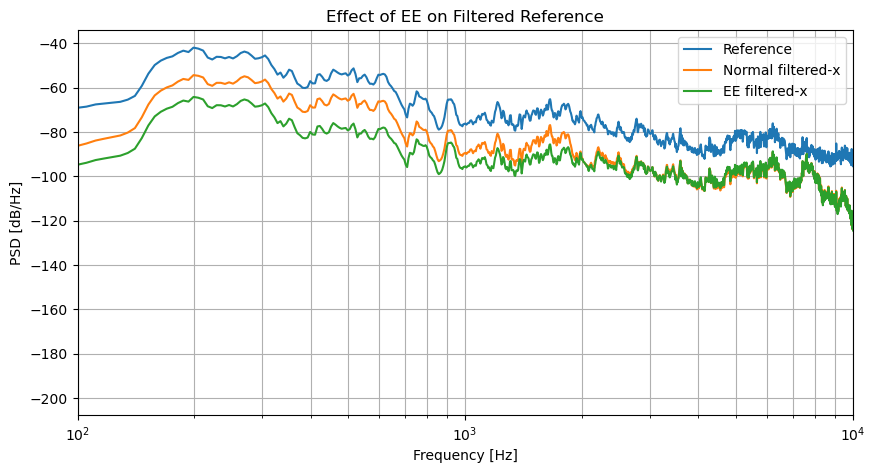

In [7]:
# Filtered-x using normal secondary-path estimate
xf_normal = fftconvolve(
    ref_nc,
    error_ir,
    mode="full"
)[:len(ref_nc)]

# Filtered-x using EE secondary-path estimate
xf_ee = fftconvolve(
    ref_nc,
    ee_ir,
    mode="full"
)[:len(ref_nc)]

nperseg = 16384

f, P_ref = welch(
    ref_nc,
    fs=fs,
    nperseg=nperseg,
)

_, P_normal = welch(
    xf_normal,
    fs=fs,
    nperseg=nperseg,
)

_, P_ee = welch(
    xf_ee,
    fs=fs,
    nperseg=nperseg,
)

eps_plot = 1e-20

plt.figure(figsize=(10, 5))

plt.semilogx(
    f,
    10*np.log10(P_ref + eps_plot),
    label="Reference"
)

plt.semilogx(
    f,
    10*np.log10(P_normal + eps_plot),
    label="Normal filtered-x"
)

plt.semilogx(
    f,
    10*np.log10(P_ee + eps_plot),
    label="EE filtered-x"
)

plt.xlim(100, 10000)
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD [dB/Hz]")
plt.title("Effect of EE on Filtered Reference")
plt.grid(True, which="both")
plt.legend()
plt.show()

In [8]:
band = (f >= 200) & (f <= 5000)

normal_db = 10*np.log10(P_normal[band] + eps_plot)
ee_db = 10*np.log10(P_ee[band] + eps_plot)

print("200-5000 Hz")
print()
print("Normal xf PSD span:", np.ptp(normal_db), "dB")
print("EE xf PSD span:    ", np.ptp(ee_db), "dB")
print()
print("Normal xf PSD std: ", np.std(normal_db), "dB")
print("EE xf PSD std:     ", np.std(ee_db), "dB")

200-5000 Hz

Normal xf PSD span: 51.925514 dB
EE xf PSD span:     41.972122 dB

Normal xf PSD std:  11.415747 dB
EE xf PSD std:      7.7412505 dB


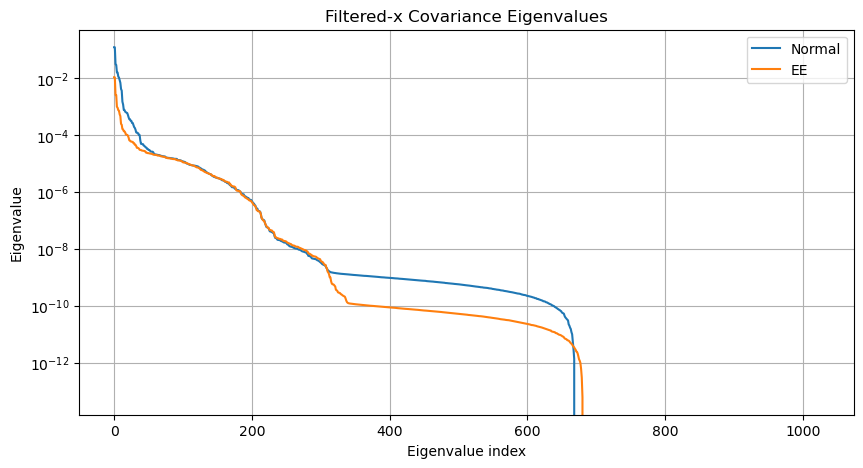

In [9]:
M = len(weights)

def covariance_eigenvalues(xf, M, fs, duration_s=2.0, stride=10):
    N = min(len(xf), int(duration_s * fs))

    x = xf[:N]

    X = sliding_window_view(x, M)
    X = X[::stride]

    X = X - X.mean(axis=0, keepdims=True)

    R = (X.T @ X) / X.shape[0]

    eigvals = np.linalg.eigvalsh(R)[::-1]

    return eigvals


eig_normal = covariance_eigenvalues(
    xf_normal,
    M,
    fs
)

eig_ee = covariance_eigenvalues(
    xf_ee,
    M,
    fs
)


plt.figure(figsize=(10, 5))

plt.semilogy(
    eig_normal + 1e-30,
    label="Normal"
)

plt.semilogy(
    eig_ee + 1e-30,
    label="EE"
)

plt.xlabel("Eigenvalue index")
plt.ylabel("Eigenvalue")
plt.title("Filtered-x Covariance Eigenvalues")
plt.grid()
plt.legend()
plt.show()

In [10]:
def eigen_metrics(eigvals, threshold_ratio=1e-12):
    largest = eigvals[0]

    retained = eigvals[
        eigvals > largest * threshold_ratio
    ]

    return {
        "largest": retained[0],
        "smallest": retained[-1],
        "condition": retained[0] / retained[-1],
        "retained": len(retained),
    }


normal_metrics = eigen_metrics(eig_normal)
ee_metrics = eigen_metrics(eig_ee)

print("Normal:")
for k, v in normal_metrics.items():
    print(f"  {k}: {v}")

print()

print("EE:")
for k, v in ee_metrics.items():
    print(f"  {k}: {v}")

Normal:
  largest: 0.12262558937072754
  smallest: 1.3735752986410166e-12
  condition: 89274744832.0
  retained: 669

EE:
  largest: 0.010838459245860577
  smallest: 6.1910566462927e-14
  condition: 175066382336.0
  retained: 681


In [12]:
bands = [
    (200, 300),
    (300, 700),
    (700, 1000),
    (1000, 2000),
    (2000, 5000),
]

def band_power(f, P, lo, hi):
    mask = (f >= lo) & (f < hi)
    return np.trapezoid(P[mask], f[mask])

print(
    f"{'Band':>15} "
    f"{'Normal xf':>15} "
    f"{'EE xf':>15} "
    f"{'EE/Normal':>12}"
)

for lo, hi in bands:
    pn = band_power(f, P_normal, lo, hi)
    pe = band_power(f, P_ee, lo, hi)

    change = 10*np.log10(
        (pe + 1e-30) /
        (pn + 1e-30)
    )

    print(
        f"{lo:5d}-{hi:<5d} Hz "
        f"{pn:15.3e} "
        f"{pe:15.3e} "
        f"{change:10.2f} dB"
    )

           Band       Normal xf           EE xf    EE/Normal
  200-300   Hz       1.906e-04       1.782e-05     -10.29 dB
  300-700   Hz       1.019e-04       6.448e-06     -11.99 dB
  700-1000  Hz       1.972e-06       3.997e-07      -6.93 dB
 1000-2000  Hz       3.424e-06       7.097e-07      -6.83 dB
 2000-5000  Hz       6.656e-07       5.544e-07      -0.79 dB


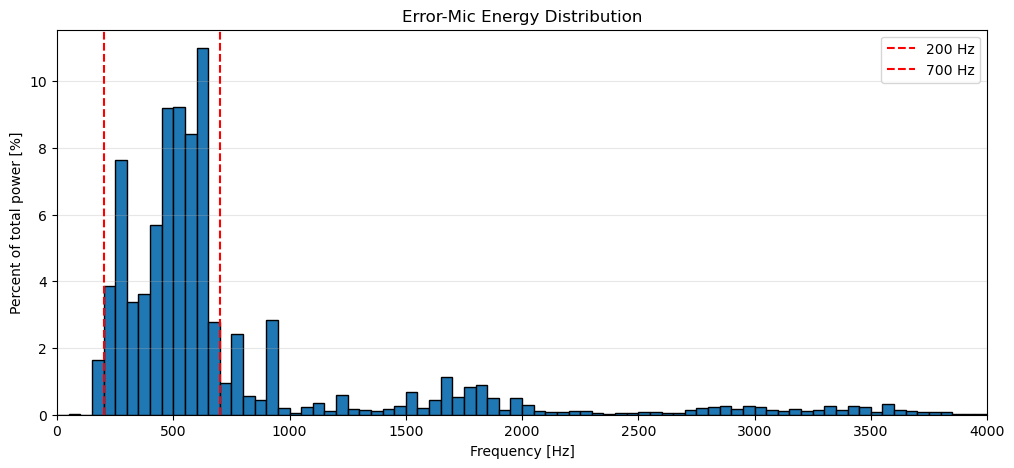

In [25]:
# PSD
f, Pxx = welch(
    error_nc,
    fs=fs,
    nperseg=16384
)

# Frequency-bin edges
edges = np.concatenate([
    np.arange(0, 4001, 50),       # 100-Hz bins to 2 kHz
])

# Total power over plotted range
mask_total = (f >= edges[0]) & (f < edges[-1])
total_power = np.trapezoid(Pxx[mask_total], f[mask_total])

percent = []

for lo, hi in zip(edges[:-1], edges[1:]):
    mask = (f >= lo) & (f < hi)
    power = np.trapezoid(Pxx[mask], f[mask])
    percent.append(100 * power / total_power)

percent = np.array(percent)

# Plot using actual frequency widths
plt.figure(figsize=(12, 5))

plt.bar(
    edges[:-1],
    percent,
    width=np.diff(edges),
    align="edge",
    edgecolor="black"
)

plt.axvline(200, linestyle="--", label="200 Hz", c='r')
plt.axvline(700, linestyle="--", label="700 Hz", c='r')

plt.xlabel("Frequency [Hz]")
plt.ylabel("Percent of total power [%]")
plt.title("Error-Mic Energy Distribution")
plt.xlim(edges[0], edges[-1])
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()